# Get started with Fire Opal on IonQ Quantum Cloud
**Solve dense max-cut instances using Fire Opal's built-in QAOA solver on IonQ quantum hardware**

[Maximum cut](https://en.wikipedia.org/wiki/Maximum_cut) (max-cut) is a classic problem in combinatorial optimization and graph theory. The aim of max-cut is to separate the nodes of a graph into two groups by intersecting as many edges between nodes as possible with a single partition, or "cut". The max-cut problem can be applied to many real-world applications across various domains, such as communications network design, image segmentation in computer vision, and financial risk management. For non-planar graphs where edges cross, there is no known polynomial-time solution, making this problem an excellent candidate for quantum optimization algorithms.

IonQ's trapped-ion architecture provides native all-to-all qubit connectivity, meaning any qubit can interact directly with any other qubit. [Fire Opal's built-in Quantum Approximate Optimization Algorithm (QAOA) solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver) can take advantage of this architecture to tackle denser, more complex max-cut instances with greater accuracy.

This guide illustrates how to solve a non-trivial, 10-node max-cut problem on IonQ hardware. By using Fire Opal's QAOA solver via the Fire Opal Python client (`fireopal`) on a highly-connected graph, the guide demonstrates how Fire Opal's QAOA solver manages the high gate density and noise inherent in dense optimization problems. The same capability is also available natively through [IonQ's Python SDK](https://docs.ionq.com/guides/qaoa-solve-with-fire-opal).

## Requirements
- An [IonQ Quantum Cloud](https://www.ionq.com/quantum-cloud) account
- A Q-CTRL account for [Fire Opal](https://q-ctrl.com/fire-opal)
- The latest version of the [Fire Opal Python package](https://docs.q-ctrl.com/fire-opal/discover/start-using/how-to-set-up-and-install-fire-opal)
- Familiarity with running Jupyter notebooks and Python environments
- Internet access

## 1. Imports and initialization

The following section sets up the necessary imports and helper functions. You can install the required packages by uncommenting and running the following cell if you are running this example in a notebook using the IPython kernel. Please note that after installing new packages, you will need to restart your notebook session or kernel for the newly installed packages to be recognized.

In [ ]:
# %pip install fire-opal matplotlib qctrl-visualizer

In [ ]:
import fireopal as fo
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
from pyscipopt import Model
import qctrlvisualizer as qv

### 1.1 Set up your accounts and choose a backend
To run this tutorial, you will need an IonQ Quantum Cloud API key. To create an API key, you can follow [IonQ's guide](https://docs.ionq.com/guides/managing-api-keys).

In [ ]:
token = ""  # IonQ API token

credentials = fo.credentials.make_credentials_for_ionq(token=token)

In [ ]:
# Enter your desired IonQ backend here.
# Valid values are ionq_simulator, ionq_qpu.forte-1, and ionq_qpu.forte-enterprise-1.
# Check device availability at https://status.ionq.co/.
backend_name = "ionq_qpu.forte-enterprise-1"

Optionally, you may also authenticate with Q-CTRL using an API key from the **Sign in and security** tab of [your Q-CTRL Accounts page](https://accounts.q-ctrl.com/). If you skip this step, you will be prompted to authenticate in your browser when calling `fo.solve_qaoa` later in this tutorial.

In [ ]:
fo.authenticate_qctrl_account(api_key="")

Q-CTRL authentication successful!


### 1.2 Define helper functions
The following functions are used to set up the max-cut problem instances and analyze results.

In [ ]:
def maxcut_obj(bitstring: str, graph: nx.Graph) -> float:
    """
    Given a bitstring, this function returns the number of edges
    shared between the two partitions of the graph.
    """
    obj = 0
    # Iterate through each edge in the graph
    for i, j, data in graph.edges(data=True):
        # Calculate the contribution of the edge to the max-cut objective
        # If the nodes are in different partitions, the term (int(bitstring[i]) - int(bitstring[j]))**2 will be 1
        # Otherwise, it will be 0
        obj -= data.get("weight", 1) * (int(bitstring[i]) - int(bitstring[j])) ** 2
    return obj


def get_cost_distribution(
    distribution: dict[str, int], graph: nx.Graph
) -> tuple[np.ndarray, np.ndarray]:
    """
    Given a bitstring count distribution and a graph, returns the
    costs and relative probabilities as numpy arrays.
    """
    # Total number of bitstrings (shots)
    shot_count = sum(distribution.values())
    costs = []
    probabilities = []
    # Calculate the cost and probability for each bitstring
    for bitstring, count in distribution.items():
        # Reverse the bitstring to match graph node indices
        cost = maxcut_obj(bitstring[::-1], graph)
        costs.append(cost)
        probabilities.append(count / shot_count)
    return np.array(costs), np.array(probabilities)


def generate_random_bitstrings(
    length: int, num_bitstrings: int, rng_seed: int = 0
) -> list[str]:
    """
    Generate a random sampling of bitstrings.
    """
    # Initialize the random number generator with a seed for reproducibility
    rng = np.random.default_rng(seed=rng_seed)
    # Generate random bitstrings
    random_array = rng.integers(0, 2, size=(num_bitstrings, length))
    bitstrings = ["".join(row.astype(str)) for row in random_array]
    return bitstrings


def calculate_percent_gap_to_optimal(
    costs: np.ndarray, optimal_cut_value: float
) -> None:
    """
    Determine the percent gap between the optimal cut value and the best cut value
    found from Fire Opal.
    """
    # Find the best cut value found (most negative cost)
    best_cut_value_found = max(-costs)
    # Calculate the percentage difference from the optimal value
    percent_optimality = np.round(
        100 - (abs(optimal_cut_value - best_cut_value_found) / optimal_cut_value * 100),
        2,
    )
    # Print the results
    print(
        f"The best cut value found by Fire Opal is {best_cut_value_found}. \n"
        f"This solution is {percent_optimality}% optimized relative to the classically determined solution, {optimal_cut_value}."
    )


def analyze_maxcut_results(
    distribution: dict[str, int], graph: nx.Graph, optimal_cut_value: float
) -> None:
    """
    Analyze results from max-cut execution.
    """
    # Number of nodes in the graph
    qubit_count = graph.number_of_nodes()
    # Total number of bitstrings (shots)
    shot_count = sum(distribution.values())

    # Get cost distribution from the results
    costs, probs = get_cost_distribution(distribution, graph)
    # Generate random bitstrings and get their cost distribution
    random_bitstrings = generate_random_bitstrings(qubit_count, shot_count)
    random_probs = np.ones(shot_count) / shot_count
    random_costs = np.asarray(
        [maxcut_obj(bitstring[::-1], graph) for bitstring in random_bitstrings]
    )

    # Plot histograms of cut values
    plt.style.use(qv.get_qctrl_style())
    _, ax = plt.subplots(1, 1)

    ax.hist(
        [-costs, -random_costs],
        np.arange(-max(random_costs), -min(costs) + 1, 1),
        weights=[probs, random_probs],
        label=["Fire Opal QAOA solver", "Random Sampling"],
        color=[qv.QCTRL_STYLE_COLORS[0], qv.QCTRL_STYLE_COLORS[1]],
    )
    ax.set_xlabel("Cut Value")
    ax.set_ylabel("Probability")
    ax.legend()

    # Calculate and print the percent gap to optimal
    calculate_percent_gap_to_optimal(costs=costs, optimal_cut_value=optimal_cut_value)


def solve_maxcut_classically(graph: nx.Graph) -> dict:
    """
    Solve the max-cut problem classically using linear programming.
    """
    model = Model("max-cut")
    # Add binary variables for edges
    e = {(u, v): model.addVar(vtype="B", name=f"e({u, v})") for u, v in graph.edges()}
    # Add binary variables for nodes
    x = {u: model.addVar(vtype="B", name=f"x({u})") for u in graph.nodes()}

    # Define the objective function to maximize the cut value
    objective = sum(
        data.get("weight", 1) * e[(u, v)] for u, v, data in graph.edges(data=True)
    )
    model.setObjective(objective, "maximize")

    # Add constraints to ensure valid cuts
    for u, v in graph.edges():
        model.addCons(e[(u, v)] <= x[u] + x[v])
        model.addCons(e[(u, v)] <= 2 - (x[u] + x[v]))

    model.hideOutput(True)
    model.optimize()

    # Ensure the solution is optimal
    assert model.getStatus() == "optimal"

    # Return the solution indicating which partition each node belongs to
    return {u: model.getVal(x[u]) for u in graph.nodes()}


def cut_value(graph: nx.Graph, cut: dict[int, float]) -> float:
    """
    Calculate the cut value of a given partition.
    """
    value = 0
    for i, j, data in graph.edges(data=True):
        value += data.get("weight", 1) * np.round(cut[i] - cut[j]) ** 2
    return value

## 2. Example: Unconstrained Optimization
Run the (max-cut) problem. The following example demonstrates the Solver's capabilities on a 10-node, unweighted graph, but you can also solve weighted graph problems.

### 2.1 Define the problem
You can run a max-cut problem by defining a graph and specifying `problem_type='maxcut'`.

In [ ]:
# Generate a random graph with 10 nodes
unweighted_graph = nx.connected_watts_strogatz_graph(n=10, k=6, p=0.5, seed=0)

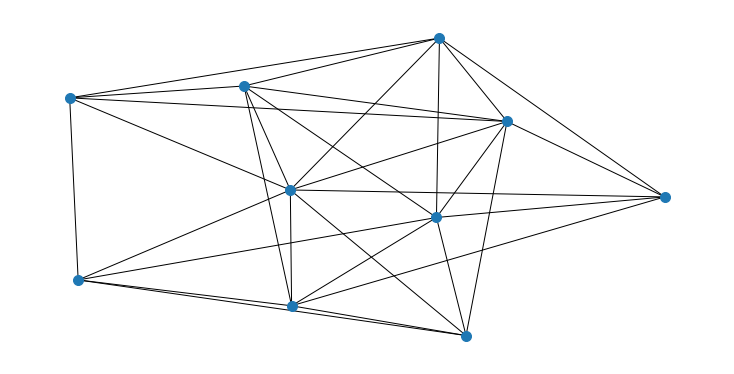

In [ ]:
# Optionally, visualize the graph
nx.draw(unweighted_graph, nx.kamada_kawai_layout(unweighted_graph), node_size=100)

### 2.2 Solve the graph problem using Fire Opal's QAOA Solver

In [ ]:
unweighted_job = fo.solve_qaoa(
    problem=unweighted_graph,
    credentials=credentials,
    problem_type="maxcut",
    backend_name=backend_name,
)

This function performs multiple consecutive runs. Wait time may vary depending on hardware queues.



In [ ]:
unweighted_result = unweighted_job.result()

### 2.3 Solve the graph problem using classical methods
Because this problem is still within the bounds of what can be solved by classical methods, it's possible to check the accuracy of Fire Opal's obtained solution.

In [ ]:
solution = solve_maxcut_classically(unweighted_graph)
optimal_cut_value = cut_value(unweighted_graph, solution)
print(f"Classically derived cut value: {optimal_cut_value}")

Classically derived cut value: 21.0


### 2.4 Plot and analyze the solutions generated by Fire Opal
The performance baseline is set by sampling bitstrings uniformly at random (red histogram bars), akin to a random brute-force scan through the solution set. The number of random samples is the same as the samples from the optimal QAOA circuit.

The best cut value found by Fire Opal is 21. 
This solution is 100.0% optimized relative to the classically determined solution, 21.0.


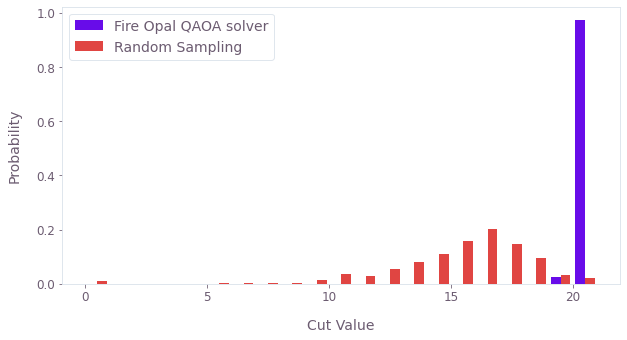

In [ ]:
analyze_maxcut_results(
    distribution=unweighted_result["final_bitstring_distribution"],
    graph=unweighted_graph,
    optimal_cut_value=optimal_cut_value,
)

In this scenario, the solutions produced by Fire Opal's QAOA solver significantly outperform the cut values obtained via random sampling, a benchmark akin to naive QAOA implementations at this scale. Fire Opal's best cut value achieves the true optimal solution with the highest probability.

Congratulations on successfully leveraging Fire Opal’s QAOA Solver to tackle a dense max-cut problem on IonQ hardware. To learn more about what sets this solver apart and how it delivers high-accuracy solutions at utility scales, explore the [Fire Opal QAOA Solver](https://docs.q-ctrl.com/fire-opal/execute/run-algorithms/solve-optimization-problems/fire-opal-qaoa-solver) technical deep dive, and a [real-world case study](https://q-ctrl.com/blog/fire-opal-native-integration-with-ionq) using the solver on IonQ hardware to minimize telecommunications network interference.

The following package versions were used to produce this notebook.

In [1]:
from fireopal import print_package_versions

print_package_versions()

| Package               | Version |
| --------------------- | ------- |
| Python                | 3.11.3  |
| networkx              | 3.5     |
| numpy                 | 2.3.1   |
| sympy                 | 1.12    |
| fire-opal             | 10.1.0  |
| qctrl-workflow-client | 9.0.1   |
